In [51]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


#---

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

#----

In [52]:
data = pd.read_csv('./data/data.csv', delimiter=',')
data

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [53]:
data.rename(columns={'Bankrupt?': 'Bankrupt'},inplace=True, errors='raise')

In [54]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt                                                  6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Interest Rate 

davanti al nome delle variabili c'è uno spazio vuoto. Rimuoviamolo 

In [55]:
data.columns = data.columns.str.strip()

In [56]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt                                                 6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate            

In [57]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


In [58]:
data.nunique()[data.nunique() == 1].index

Index(['Net Income Flag'], dtype='str')

In [59]:
data = data.drop(columns=['Net Income Flag'])

In [60]:
data.shape

(6819, 95)

In [61]:
data['Bankrupt'].value_counts(normalize=True)*100

Bankrupt
0    96.77372
1     3.22628
Name: proportion, dtype: float64

/var/folders/5j/kzr37g_111d6wf3j1vvwzcj80000gn/T/ipykernel_16788/1197128513.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Bankrupt', data=data, palette="blend:#7AB,#EDA")


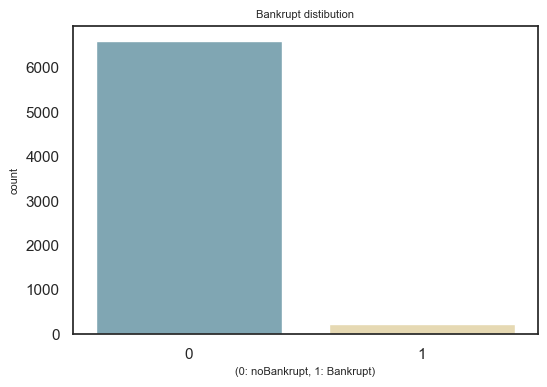

In [62]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Bankrupt', data=data, palette="blend:#7AB,#EDA")

plt.title('Bankrupt distibution', fontsize=8)
plt.xlabel('(0: noBankrupt, 1: Bankrupt)', fontsize=8)
plt.ylabel('count', fontsize=8)

plt.show()

Il dataset è sbilanciato, solamente il $\approx$ 3.3% del dataset ha il target = 1 -> il 3.3% delle aziende è andata in bancarotta. 

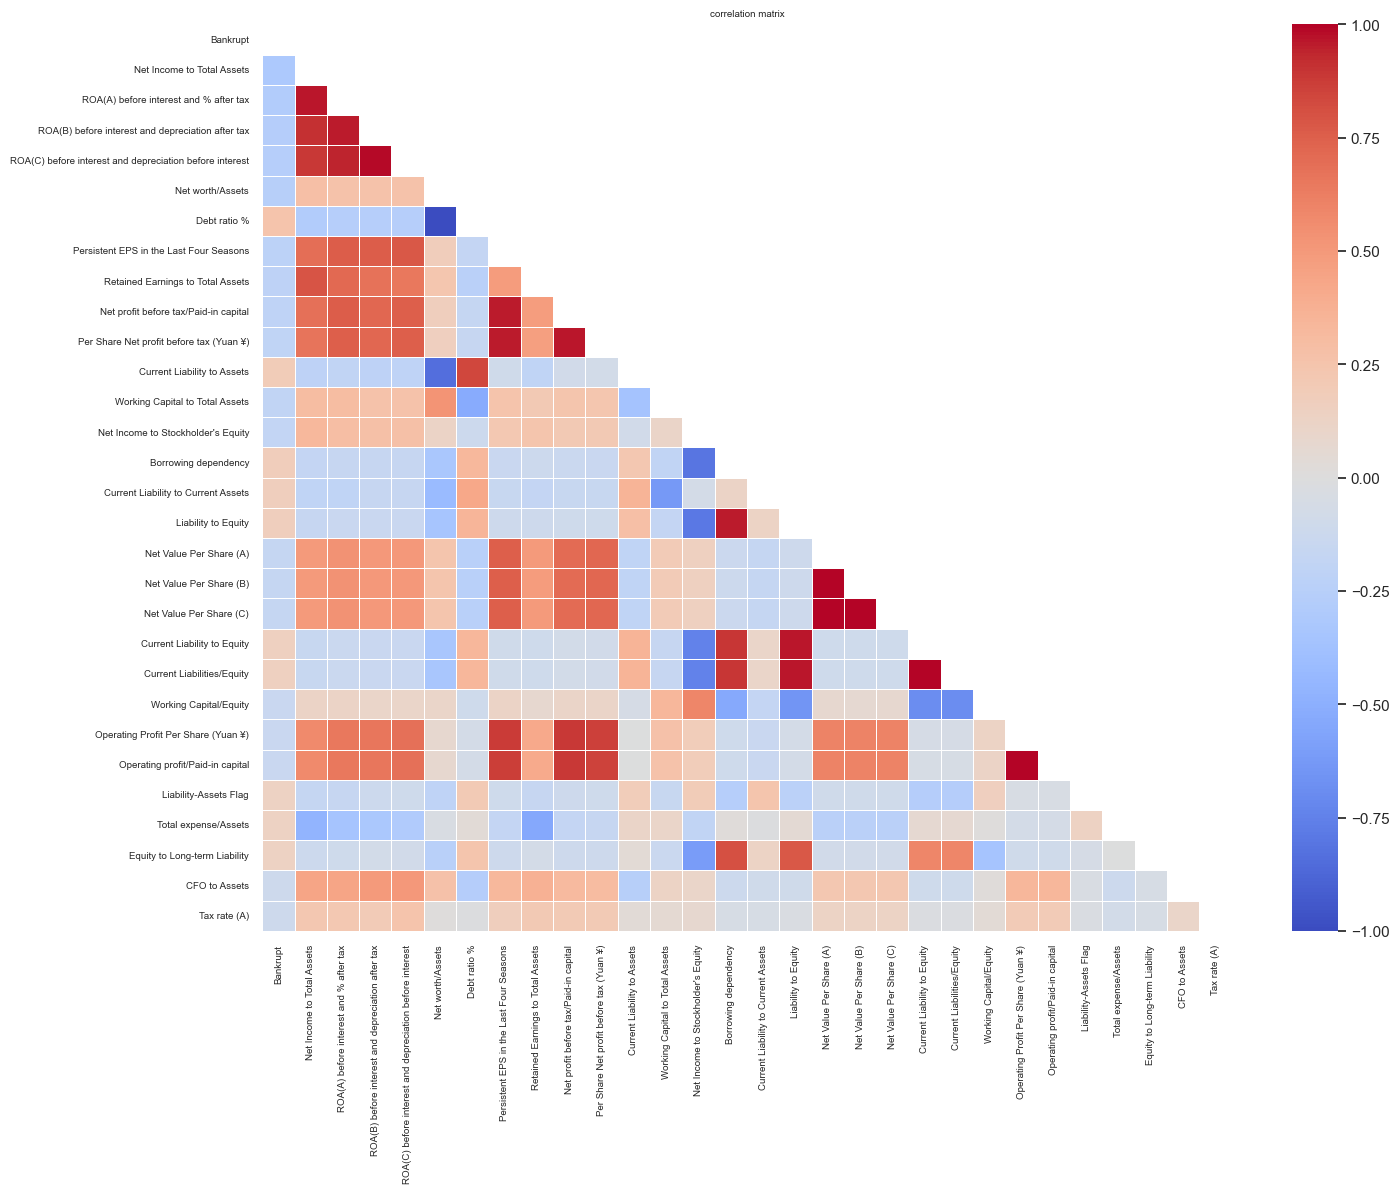

In [63]:
corr = data.corr()
top_corr = corr['Bankrupt'].abs().sort_values(ascending=False).head(30).index

mask = np.triu(np.ones_like(corr.loc[top_corr, top_corr], dtype=bool))
sns.set_theme(style="white")

f, ax = plt.subplots(figsize=(15, 12))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr.loc[top_corr, top_corr], 
            annot=False,            
            cmap='coolwarm',       
            fmt=".1f",
            mask=mask,
            linewidths=0.6
            )
plt.xticks(fontsize=7) 
plt.yticks(fontsize=7)
plt.tight_layout()

plt.title('correlation matrix', fontsize=7)
plt.show()


In [64]:
# data preprocessing 
X = data.drop(['Bankrupt'], axis=1)
y = data['Bankrupt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Varianza spiegata da ciascuna PC: [0.13860629 0.07303359]
Varianza totale spiegata: 0.21163987698874429


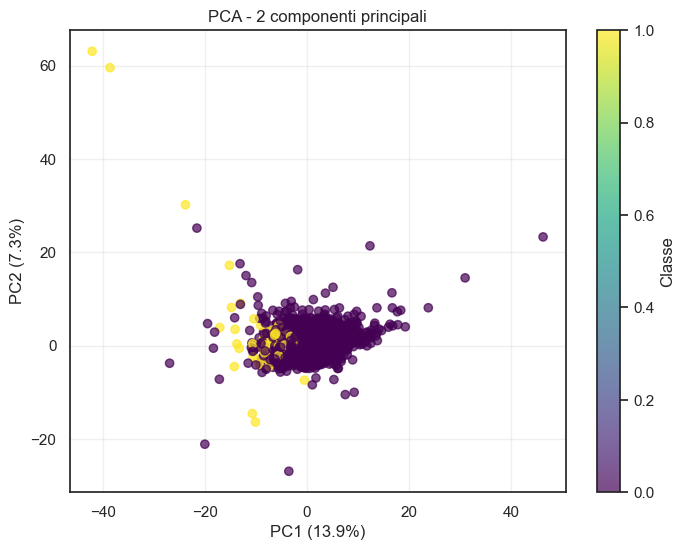

In [65]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print("Varianza spiegata da ciascuna PC:", pca.explained_variance_ratio_)
print("Varianza totale spiegata:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA - 2 componenti principali')
plt.colorbar(label='Classe')
plt.grid(True, alpha=0.3)
plt.show()

In [66]:
pca.components_

array([[ 2.33927484e-01,  2.35854018e-01,  2.32172821e-01,
         1.15781102e-01,  1.15366062e-01,  3.09602347e-02,
         3.48237157e-02,  3.21841739e-02,  2.84368310e-02,
         3.29473354e-02,  9.05886744e-03,  2.68327552e-02,
         1.15966013e-01,  2.01701583e-02,  5.97802758e-02,
         1.93303711e-01,  1.93443165e-01,  1.93389347e-01,
         2.32599052e-01,  1.31109254e-01,  7.42291913e-03,
         2.09437471e-01,  2.29083826e-01, -4.32043432e-03,
         1.38760065e-02,  3.18513598e-02,  3.18019080e-02,
         9.09923239e-03,  3.35144993e-03, -3.98369063e-03,
         1.74258614e-02,  1.07035729e-01,  4.33263565e-02,
        -8.30347865e-03, -3.09245118e-03,  1.25630845e-02,
        -1.35705688e-01,  1.35705688e-01,  1.58254656e-02,
        -1.18842348e-01, -4.35976922e-02,  2.08450219e-01,
         2.27862872e-01, -8.88186543e-02,  4.30653110e-02,
        -7.36088201e-03, -1.40479659e-03, -1.61706064e-02,
        -3.57995568e-02, -1.15115389e-02, -1.19493695e-0

In [67]:

loads = pca.components_
pc = 0

ordine = np.argsort(np.abs(loads[pc]))[::-1]  
print(f"Top 5 Feature più importanti nella PC{pc+1}:")

for i in ordine[:5]:
    nome_variabile = X.columns[i] 
    print(f"  {nome_variabile}: {loads[pc, i]:.3f}")

Top 5 Feature più importanti nella PC1:
  ROA(A) before interest and % after tax: 0.236
  ROA(C) before interest and depreciation before interest: 0.234
  Persistent EPS in the Last Four Seasons: 0.233
  ROA(B) before interest and depreciation after tax: 0.232
  Per Share Net profit before tax (Yuan ¥): 0.229


Queste feature hanno un peso positivo sulla PC1. -> 

[0.13860629 0.07303359 0.06785628 0.05381926 0.0491583  0.03510452
 0.03204797 0.02852112 0.02563525 0.02097195 0.02044958 0.01904472
 0.01788933 0.01603895 0.01523665 0.01467939 0.01391681 0.01317672
 0.01270156 0.01199709 0.01191992 0.01138003 0.01124537]
0.13860628826558985


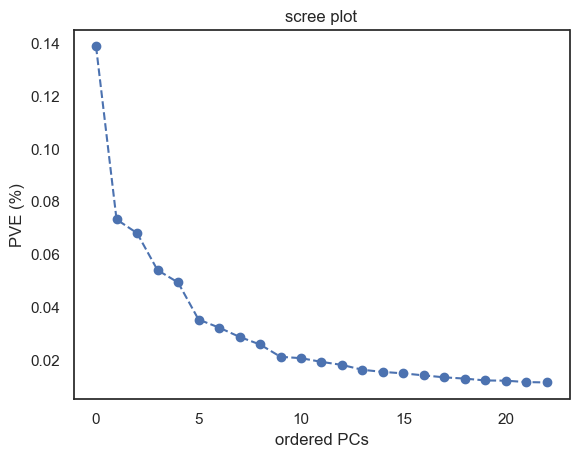

In [68]:
pca_model = PCA(n_components=23)
pca_coordinates = pca_model.fit_transform(X_train_scaled)
plt.plot(pca_model.explained_variance_ratio_, linestyle='--', marker='o', color='b')
plt.title('scree plot')
plt.xlabel('ordered PCs')
plt.ylabel('PVE (%)')
print(pca_model.explained_variance_ratio_)
print(np.sum(pca_model.explained_variance_ratio_[:1]))

In [69]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# 3. Calcolo metriche per il Training Set
training_acc = accuracy_score(y_train, y_pred_train)
training_ba = balanced_accuracy_score(y_train, y_pred_train)
training_recall = recall_score(y_train, y_pred_train)
training_precision = precision_score(y_train, y_pred_train)
training_f1 = f1_score(y_train, y_pred_train)
training_roc_auc = roc_auc_score(y_train, y_pred_train)

# 4. Calcolo metriche per il Testing Set
testing_acc = accuracy_score(y_test, y_pred_test)
testing_ba = balanced_accuracy_score(y_test, y_pred_test)
testing_recall = recall_score(y_test, y_pred_test)
testing_precision = precision_score(y_test, y_pred_test)
testing_f1 = f1_score(y_test, y_pred_test)
testing_roc_auc = roc_auc_score(y_test, y_pred_test)

# --- 5. Stampa dei Risultati in Tabella Perfettamente Allineata ---
print(f"{'SET':<10} | {'ACC':<6} | {'BA':<6} | {'RECALL':<6} | {'PRECISION':<9} | {'F1':<6} | {'ROC-AUC':<7}")
print("-" * 65)
print(f"{'Training':<10} | {training_acc:.3f} | {training_ba:.3f} | {training_recall:.3f}  | {training_precision:.3f}     | {training_f1:.3f} | {training_roc_auc:.3f}")
print(f"{'Testing':<10} | {testing_acc:.3f} | {testing_ba:.3f} | {testing_recall:.3f}  | {testing_precision:.3f}     | {testing_f1:.3f} | {testing_roc_auc:.3f}")

SET        | ACC    | BA     | RECALL | PRECISION | F1     | ROC-AUC
-----------------------------------------------------------------
Training   | 0.975 | 0.625 | 0.254  | 0.706     | 0.373 | 0.625
Testing    | 0.962 | 0.574 | 0.154  | 0.500     | 0.235 | 0.574


In [70]:
#smote

smote = SMOTE(random_state=42, sampling_strategy='minority')
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
y_train_smote.value_counts()



Bankrupt
0    4631
1    4631
Name: count, dtype: int64

Varianza spiegata da ciascuna PC: [0.32680301 0.13651972]
Varianza totale spiegata: 0.4633227362237666


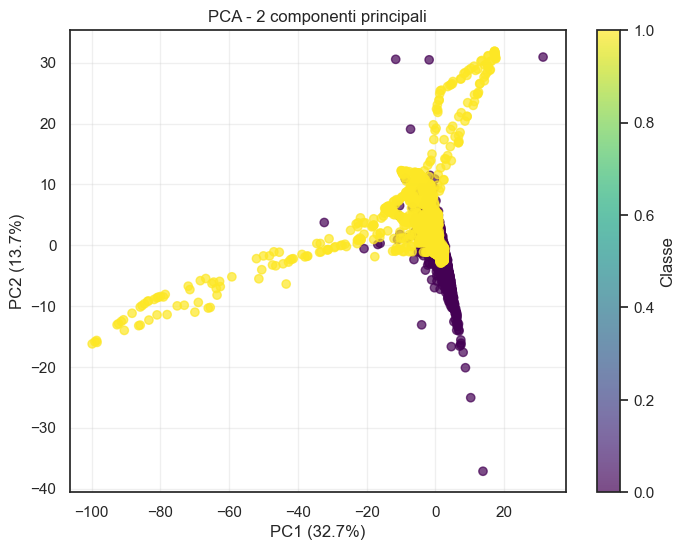

In [71]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_smote)

# --- 3. Risultati ---
print("Varianza spiegata da ciascuna PC:", pca.explained_variance_ratio_)
print("Varianza totale spiegata:", pca.explained_variance_ratio_.sum())

# --- 4. Visualizzazione ---
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_smote, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA - 2 componenti principali')
plt.colorbar(label='Classe')
plt.grid(True, alpha=0.3)
plt.show()

In [72]:

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Verifica il bilanciamento (ora saranno 50% sani e 50% falliti nel train)
print("Distribuzione classi dopo SMOTE nel Train:", y_train_resampled.value_counts())

# 2. Inizializziamo la Regressione Logistica STANDARD (SENZA class_weight='balanced')
model_smote = LogisticRegression(random_state=42, max_iter=1000) # <--- Niente class_weight qui!

# 3. Fit sui dati bilanciati sinteticamente dallo SMOTE
model_smote.fit(X_train_resampled, y_train_resampled)

# 4. Predizione sul Test Set originale scalato (il Test Set non va MAI toccato dallo SMOTE!)
y_pred_train_smote = model_smote.predict(X_train_scaled)
y_pred_test_smote = model_smote.predict(X_test_scaled)

# 3. Calcolo metriche per il Training Set
training_acc = accuracy_score(y_train, y_pred_train_smote)
training_ba = balanced_accuracy_score(y_train, y_pred_train_smote)
training_recall = recall_score(y_train, y_pred_train_smote)
training_precision = precision_score(y_train, y_pred_train_smote)
training_f1 = f1_score(y_train, y_pred_train_smote)
training_roc_auc = roc_auc_score(y_train, y_pred_train_smote)

# 4. Calcolo metriche per il Testing Set
testing_acc = accuracy_score(y_test, y_pred_test_smote)
testing_ba = balanced_accuracy_score(y_test, y_pred_test_smote)
testing_recall = recall_score(y_test, y_pred_test_smote)
testing_precision = precision_score(y_test, y_pred_test_smote)
testing_f1 = f1_score(y_test, y_pred_test_smote)
testing_roc_auc = roc_auc_score(y_test, y_pred_test_smote)

# --- 5. Stampa dei Risultati in Tabella Perfettamente Allineata ---
print(f"{'SET':<10} | {'ACC':<6} | {'BA':<6} | {'RECALL':<6} | {'PRECISION':<9} | {'F1':<6} | {'ROC-AUC':<7}")
print("-" * 65)
print(f"{'Training':<10} | {training_acc:.3f} | {training_ba:.3f} | {training_recall:.3f}  | {training_precision:.3f}     | {training_f1:.3f} | {training_roc_auc:.3f}")
print(f"{'Testing':<10} | {testing_acc:.3f} | {testing_ba:.3f} | {testing_recall:.3f}  | {testing_precision:.3f}     | {testing_f1:.3f} | {testing_roc_auc:.3f}")

Distribuzione classi dopo SMOTE nel Train: Bankrupt
0    4631
1    4631
Name: count, dtype: int64
SET        | ACC    | BA     | RECALL | PRECISION | F1     | ROC-AUC
-----------------------------------------------------------------
Training   | 0.882 | 0.871 | 0.859  | 0.184     | 0.303 | 0.871
Testing    | 0.872 | 0.798 | 0.718  | 0.190     | 0.300 | 0.798


In [ ]:
from sklearn.model_selection import GridSearchCV

base_model = LogisticRegression(max_iter=1000, random_state=42)

param_grid = {
    'penalty': ['l1'],
    'solver': ['liblinear'], 
    'C': [0.1, 1.0]     
}

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Migliori iperparametri:", grid_search.best_params_)
print(f"Miglior F1-Score in Cross-Validation: {grid_search.best_score_:.3f}")

# Predizioni DEL GRIDSEARCH
y_pred_train = grid_search.predict(X_train_scaled)  
y_pred_test  = grid_search.predict(X_test_scaled)

# Metriche Training
training_acc       = accuracy_score(y_train, y_pred_train)
training_ba        = balanced_accuracy_score(y_train, y_pred_train)
training_recall    = recall_score(y_train, y_pred_train)
training_precision = precision_score(y_train, y_pred_train)
training_f1        = f1_score(y_train, y_pred_train)
training_roc_auc   = roc_auc_score(y_train, y_pred_train)

# Metriche Testing
testing_acc       = accuracy_score(y_test, y_pred_test)
testing_ba        = balanced_accuracy_score(y_test, y_pred_test)
testing_recall    = recall_score(y_test, y_pred_test)
testing_precision = precision_score(y_test, y_pred_test)
testing_f1        = f1_score(y_test, y_pred_test)
testing_roc_auc   = roc_auc_score(y_test, y_pred_test)

# --- 5. Stampa dei Risultati in Tabella Perfettamente Allineata ---
print(f"{'SET':<10} | {'ACC':<6} | {'BA':<6} | {'RECALL':<6} | {'PRECISION':<9} | {'F1':<6} | {'ROC-AUC':<7}")
print("-" * 65)
print(f"{'Training':<10} | {training_acc:.3f} | {training_ba:.3f} | {training_recall:.3f}  | {training_precision:.3f}     | {training_f1:.3f} | {training_roc_auc:.3f}")
print(f"{'Testing':<10} | {testing_acc:.3f} | {testing_ba:.3f} | {testing_recall:.3f}  | {testing_precision:.3f}     | {testing_f1:.3f} | {testing_roc_auc:.3f}")

/opt/miniconda3/envs/env1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/env1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/env1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 

Migliori iperparametri: {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}
Miglior F1-Score in Cross-Validation: 0.901
SET        | ACC    | BA     | RECALL | PRECISION | F1     | ROC-AUC
-----------------------------------------------------------------
Training   | 0.883 | 0.871 | 0.859  | 0.185     | 0.304 | 0.871
Testing    | 0.871 | 0.810 | 0.744  | 0.193     | 0.306 | 0.810
